In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import os
import cv2
from PIL import Image

In [ ]:

def load_images_from_folder(folder):
    images = []
    for subdir, dirs, files in os.walk(folder):
        for filename in files:
            filepath = os.path.join(subdir, filename)
            img = cv2.imread(filepath)
            if img is not None:
                images.append(img)
    return images

def get_image_paths(folder):
    image_paths = []
    for subdir, dirs, files in os.walk(folder):
        for filename in files:
            filepath = os.path.join(subdir, filename)
            image_paths.append(filepath)
    return image_paths

def crop_image(source_dir, dest_dir, aspect_ratio):
    # crops images to the specified aspect ratio

    # Create destination directory if it does not exist
    os.makedirs(dest_dir, exist_ok=True)

    # Loop through all files in the source directory
    for filename in os.listdir(source_dir):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):  # Check for image files
            file_path = os.path.join(source_dir, filename)
            
            # Read image
            img = cv2.imread(file_path)
            if img is None:
                continue
            
            # Get dimensions
            height, width = img.shape[:2]
            
            # Calculate new dimensions
            if width / height > aspect_ratio:  # Too wide
                new_width = int(height * aspect_ratio)
                x_start = (width - new_width) // 2
                img_cropped = img[:, x_start:x_start + new_width]
            else:  # Too tall
                new_height = int(width / aspect_ratio)
                y_start = (height - new_height) // 2
                img_cropped = img[y_start:y_start + new_height, :]

            # Save cropped image
            cv2.imwrite(os.path.join(dest_dir, filename), img_cropped)

def resize_image(source_dir, dest_dir, target_width, target_height):
    # resizes images to the specified dimensions
    # images should have the correct aspect ratio before resizing
    # discards images that are too small

    # Create destination directory if it does not exist
    os.makedirs(dest_dir, exist_ok=True)

    # Loop through all files in the source directory
    discarded_count = 0
    for filename in os.listdir(source_dir):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):  # Check for image files
            file_path = os.path.join(source_dir, filename)
            
            # Read image
            img = cv2.imread(file_path)
            if img is None:
                continue
            
            # Get dimensions
            height, width = img.shape[:2] 
            
            # Check size and process accordingly
            if width < target_width or height < target_height:
                # Discard images that are too small
                print(f"Discarded: {filename} - size too small ({width}x{height})")
                discarded_count += 1
                continue
            elif width == target_width and height == target_height:
                # Copy over images that are already the right size
                cv2.imwrite(os.path.join(dest_dir, filename), img)
            else:
                # Resize images that are not the right size
                img_resized = cv2.resize(img, (target_width, target_height))
                cv2.imwrite(os.path.join(dest_dir, filename), img_resized)
                
    print(f"Discarded {discarded_count} images due to size.")

def rotate_images(source_folder, destination_folder):
    # Rotate images that are wider than they are tall by 90 degrees clockwise

    # Ensure destination folder exists, if not, create it
    os.makedirs(destination_folder, exist_ok=True)

    # Walk through all files in the source folder
    for subdir, dirs, files in os.walk(source_folder):
        for filename in files:
            filepath = os.path.join(subdir, filename)
            img = cv2.imread(filepath)
            if img is not None:
                # Check if the image is wider than it is tall
                h, w = img.shape[:2]
                if w > h:
                    # Rotate the image by 90 degrees
                    rotated_img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
                    save_path = os.path.join(destination_folder, filename)
                    cv2.imwrite(save_path, rotated_img)
                else:
                    # Copy the image without any changes
                    save_path = os.path.join(destination_folder, filename)
                    cv2.imwrite(save_path, img)

def get_image_sizes(folder):
    image_sizes = load_images_from_folder(folder)

    image_heights = [image.shape[0] for image in image_sizes]
    image_widths = [image.shape[1] for image in image_sizes]

    return image_heights, image_widths

def plot_size_scatter(NORMAL_image_widths, NORMAL_image_heights, PNEUMONIA_image_widths, PNEUMONIA_image_heights):

    plt.scatter(NORMAL_image_widths, NORMAL_image_heights, color='red', label='Normal Set')
    plt.scatter(PNEUMONIA_image_widths, PNEUMONIA_image_heights, color='blue', label='Pneumonia Set')

    plt.xlabel('Image Width')
    plt.ylabel('Image Height')
    plt.title('Image Height x Width Scatter Plot')
    plt.legend()
    plt.show()

def plot_aspect_ratio_histogram(NORMAL_image_widths, NORMAL_image_heights, PNEUMONIA_image_widths, PNEUMONIA_image_heights):
    aspect_ratios_normal = np.array(NORMAL_image_heights) / np.array(NORMAL_image_widths)
    aspect_ratios_pheumonia = np.array(PNEUMONIA_image_heights) / np.array(PNEUMONIA_image_widths)

    # Define the bins
    max_value = max(aspect_ratios_normal.max(), aspect_ratios_pheumonia.max())
    bins = np.linspace(0, max_value, 11)  # Adjust number of bins as needed

    # Compute the histograms for each dataset
    hist_normal, _ = np.histogram(aspect_ratios_normal, bins=bins)
    hist_another, _ = np.histogram(aspect_ratios_pheumonia, bins=bins)

    # Plot the stacked bar graph
    fig, ax = plt.subplots()

    # Stacked bar chart
    ax.bar(bins[:-1], hist_normal, width=bins[1]-bins[0], label='Normal Set')
    ax.bar(bins[:-1], hist_another, width=bins[1]-bins[0], bottom=hist_normal, label='Pheumonia Set')

    # Labels and title
    ax.set_xlabel('Aspect Ratio')
    ax.set_ylabel('Frequency')
    ax.set_title('Aspect Ratio Stacked Histogram')
    ax.legend()

    # Show the plot
    plt.show()

In [ ]:
NORMAL_image_heights, NORMAL_image_widths = get_image_sizes('chest_xray/train/NORMAL')
PNEUMONIA_image_heights, PNEUMONIA_image_widths = get_image_sizes('chest_xray/train/PNEUMONIA')

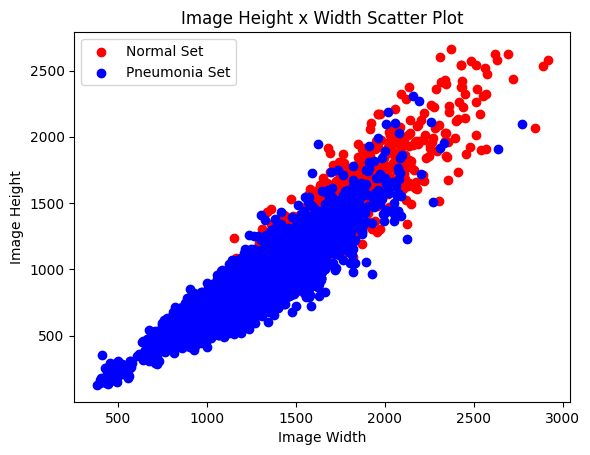

In [ ]:
plot_size_scatter(NORMAL_image_widths, NORMAL_image_heights, PNEUMONIA_image_widths, PNEUMONIA_image_heights)

From this plot we can see we have images of widely varying resolutions and aspect ratios.

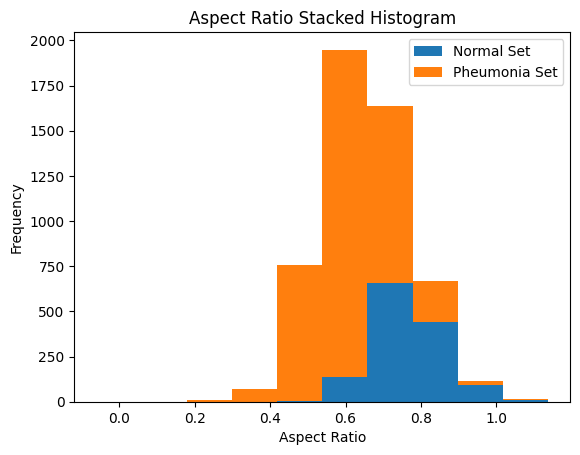

In [ ]:
plot_aspect_ratio_histogram(NORMAL_image_widths, NORMAL_image_heights, PNEUMONIA_image_widths, PNEUMONIA_image_heights)


The histograms show that the average aspect ratios of the postive and negative images vary slighty. I will take 0.7 

In [ ]:

# thjis didn't work for me


# Define the source and destination directories
source_dir = './chest_xray/train/NORMAL'
destination_dir = './chest_xray/CROPPED/train/NORMAL'

# Create the destination directory if it doesn't exist
os.makedirs(destination_dir, exist_ok=True)

# Loop through the images in the source directory
for filename in os.listdir(source_dir):
    # Load the image
    image_path = os.path.join(source_dir, filename)
    image = Image.open(image_path)
    
    # Calculate the desired width based on the aspect ratio
    height, width = image.size
    desired_width = int(height * 0.7)
    
    # Calculate the cropping coordinates
    left = (width - desired_width) // 2
    right = left + desired_width
    
    # Crop the image
    cropped_image = image.crop((left, 0, right, height))
    
    # Save the cropped image to the destination directory
    #destination_path = os.path.join(destination_dir, filename)
    #cropped_image.save(destination_path)


In [ ]:
# Source and destination directories
crop_image('./chest_xray/train/NORMAL', './chest_xray/CROPPED-0.7/train/NORMAL', 0.7)
crop_image('./chest_xray/train/PNEUMONIA', './chest_xray/CROPPED-0.7/train/PNEUMONIA', 0.7)

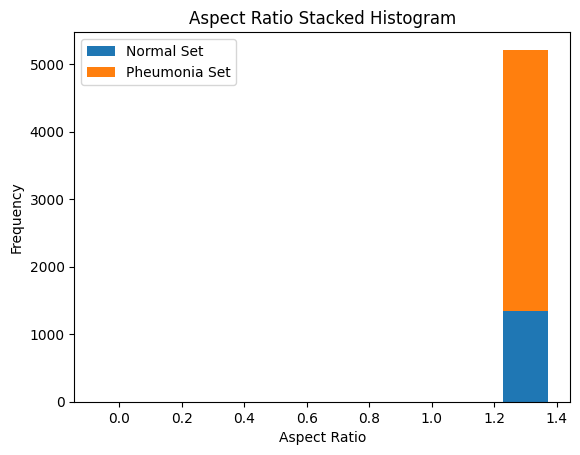

In [ ]:
NORMAL_image_heights_07, NORMAL_image_widths_07 = get_image_sizes('./chest_xray/CROPPED-0.7/train/NORMAL')
PNEUMONIA_image_heights_07, PNEUMONIA_image_widths_07 = get_image_sizes('./chest_xray/CROPPED-0.7/train/PNEUMONIA')
plot_aspect_ratio_histogram(NORMAL_image_widths_07, NORMAL_image_heights_07, PNEUMONIA_image_widths_07, PNEUMONIA_image_heights_07)

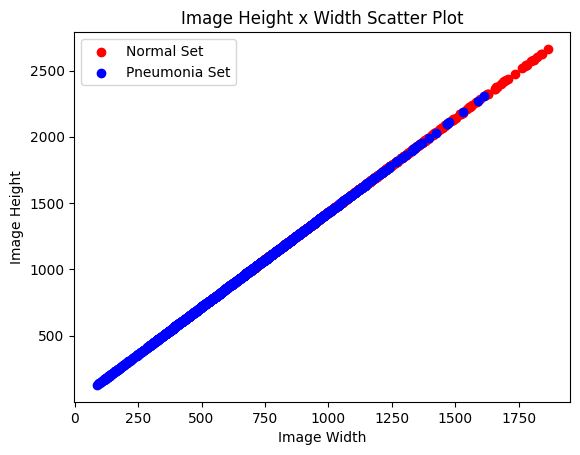

In [ ]:
plot_size_scatter(NORMAL_image_widths_07, NORMAL_image_heights_07, PNEUMONIA_image_widths_07, PNEUMONIA_image_heights_07)

In [ ]:
resize_image('./chest_xray/CROPPED-0.7/train/NORMAL', './chest_xray/PROCESSED-0.7/train/NORMAL', 595, 850)

Discarded: IM-0158-0001.jpeg - size too small (530x758)
Discarded: IM-0164-0001.jpeg - size too small (565x808)
Discarded: IM-0199-0001.jpeg - size too small (583x833)
Discarded: IM-0206-0001.jpeg - size too small (522x747)
Discarded: IM-0314-0001.jpeg - size too small (592x846)
Discarded: IM-0333-0001.jpeg - size too small (590x843)
Discarded: IM-0370-0001.jpeg - size too small (582x832)
Discarded: IM-0409-0001.jpeg - size too small (555x793)
Discarded: IM-0435-0001.jpeg - size too small (581x831)
Discarded: IM-0696-0001.jpeg - size too small (589x842)
Discarded: IM-0732-0001.jpeg - size too small (560x800)
Discarded: IM-0739-0001.jpeg - size too small (570x815)
Discarded: NORMAL2-IM-0588-0001.jpeg - size too small (565x808)
Discarded: NORMAL2-IM-0665-0001.jpeg - size too small (538x769)
Discarded: NORMAL2-IM-0725-0001.jpeg - size too small (576x824)
Discarded: NORMAL2-IM-0872-0001.jpeg - size too small (562x804)
Discarded: NORMAL2-IM-1241-0001.jpeg - size too small (554x792)
Discarde

In [ ]:
resize_image('./chest_xray/CROPPED-0.7/train/PNEUMONIA', './chest_xray/PROCESSED-0.7/train/PNEUMONIA', 595, 850)

Discarded: person1000_bacteria_2931.jpeg - size too small (532x760)
Discarded: person1000_virus_1681.jpeg - size too small (537x768)
Discarded: person1003_virus_1685.jpeg - size too small (431x616)
Discarded: person1004_bacteria_2935.jpeg - size too small (571x816)
Discarded: person1004_virus_1686.jpeg - size too small (336x480)
Discarded: person1005_virus_1688.jpeg - size too small (554x792)
Discarded: person1007_bacteria_2938.jpeg - size too small (543x776)
Discarded: person1007_virus_1690.jpeg - size too small (464x664)
Discarded: person1008_bacteria_2939.jpeg - size too small (554x792)
Discarded: person100_virus_184.jpeg - size too small (554x792)
Discarded: person1010_virus_1695.jpeg - size too small (214x307)
Discarded: person1011_bacteria_2942.jpeg - size too small (364x520)
Discarded: person1012_bacteria_2943.jpeg - size too small (475x680)
Discarded: person1016_bacteria_2947.jpeg - size too small (459x656)
Discarded: person1017_bacteria_2948.jpeg - size too small (501x716)
Dis

In [ ]:
rotate_images('./chest_xray/CROPPED-0.7/train/PNEUMONIA', './chest_xray/ROTATED-0.7/train/PNEUMONIA')
resize_image('./chest_xray/ROTATED-0.7/train/PNEUMONIA', './chest_xray/PROCESSED-0.7/train/PNEUMONIA_ROTATED',595, 850)

Discarded: person1000_bacteria_2931.jpeg - size too small (532x760)
Discarded: person1000_virus_1681.jpeg - size too small (537x768)
Discarded: person1003_virus_1685.jpeg - size too small (431x616)
Discarded: person1004_bacteria_2935.jpeg - size too small (571x816)
Discarded: person1004_virus_1686.jpeg - size too small (336x480)
Discarded: person1005_virus_1688.jpeg - size too small (554x792)
Discarded: person1007_bacteria_2938.jpeg - size too small (543x776)
Discarded: person1007_virus_1690.jpeg - size too small (464x664)
Discarded: person1008_bacteria_2939.jpeg - size too small (554x792)
Discarded: person100_virus_184.jpeg - size too small (554x792)
Discarded: person1010_virus_1695.jpeg - size too small (214x307)
Discarded: person1011_bacteria_2942.jpeg - size too small (364x520)
Discarded: person1012_bacteria_2943.jpeg - size too small (475x680)
Discarded: person1016_bacteria_2947.jpeg - size too small (459x656)
Discarded: person1017_bacteria_2948.jpeg - size too small (501x716)
Dis

Far too many of the positive images where discarded as they're smaller on average than the normal images. I didn't spot this above because I looked at all data in the plots. I'll need to re-evaluate my selected aspect ratio and dimensions.

In [ ]:
crop_image('./chest_xray/train/NORMAL', './chest_xray/CROPPED-1.0/train/NORMAL', aspect_ratio=1.0)
crop_image('./chest_xray/train/PNEUMONIA', './chest_xray/CROPPED-1.0/train/PNEUMONIA', aspect_ratio=1.0)

In [ ]:
resize_image('./chest_xray/CROPPED-1.0/train/NORMAL', './chest_xray/PROCESSED-1.0/train/NORMAL', target_width=244, target_height=244)

Discarded 0 images due to size.


In [ ]:
resize_image('./chest_xray/CROPPED-1.0/train/PNEUMONIA', './chest_xray/PROCESSED-1.0/train/PNEUMONIA', target_width=244, target_height=244)

Discarded: person1308_bacteria_3292.jpeg - size too small (209x209)
Discarded: person1311_bacteria_3312.jpeg - size too small (189x189)
Discarded: person1669_bacteria_4422.jpeg - size too small (163x163)
Discarded: person1676_bacteria_4441.jpeg - size too small (178x178)
Discarded: person1677_bacteria_4444.jpeg - size too small (198x198)
Discarded: person1679_bacteria_4448.jpeg - size too small (167x167)
Discarded: person1679_bacteria_4449.jpeg - size too small (168x168)
Discarded: person1679_bacteria_4450.jpeg - size too small (229x229)
Discarded: person1684_bacteria_4461.jpeg - size too small (188x188)
Discarded: person1684_bacteria_4462.jpeg - size too small (151x151)
Discarded: person1689_bacteria_4474.jpeg - size too small (144x144)
Discarded: person1693_bacteria_4485.jpeg - size too small (164x164)
Discarded: person1702_bacteria_4506.jpeg - size too small (179x179)
Discarded: person1705_bacteria_4515.jpeg - size too small (232x232)
Discarded: person1706_bacteria_4516.jpeg - size 

In [ ]:
rotate_images('./chest_xray/CROPPED-1.0/train/PNEUMONIA', './chest_xray/ROTATED-1.0/train/PNEUMONIA')
resize_image('./chest_xray/CROPPED-1.0/train/PNEUMONIA', './chest_xray/PROCESSED-1.0/train/PNEUMONIA_ROTATED', target_width=244, target_height=244)

Discarded: person1308_bacteria_3292.jpeg - size too small (209x209)
Discarded: person1311_bacteria_3312.jpeg - size too small (189x189)
Discarded: person1669_bacteria_4422.jpeg - size too small (163x163)
Discarded: person1676_bacteria_4441.jpeg - size too small (178x178)
Discarded: person1677_bacteria_4444.jpeg - size too small (198x198)
Discarded: person1679_bacteria_4448.jpeg - size too small (167x167)
Discarded: person1679_bacteria_4449.jpeg - size too small (168x168)
Discarded: person1679_bacteria_4450.jpeg - size too small (229x229)
Discarded: person1684_bacteria_4461.jpeg - size too small (188x188)
Discarded: person1684_bacteria_4462.jpeg - size too small (151x151)
Discarded: person1689_bacteria_4474.jpeg - size too small (144x144)
Discarded: person1693_bacteria_4485.jpeg - size too small (164x164)
Discarded: person1702_bacteria_4506.jpeg - size too small (179x179)
Discarded: person1705_bacteria_4515.jpeg - size too small (232x232)
Discarded: person1706_bacteria_4516.jpeg - size 

In [ ]:
image_sizes = load_images_from_folder('./chest_xray/PROCESSED/train')

image_heights = [image.shape[0] for image in image_sizes]
image_widths = [image.shape[1] for image in image_sizes]

# Loop through the image sizes and calculate the aspect ratios
aspect_ratios = np.array(image_heights) / np.array(image_widths)

# Create a dictionary to store the unique image sizes and their counts
image_size_counts = {}

# Loop through the image sizes and count the occurrences
for size in image_sizes:
    if size.shape in image_size_counts:
        image_size_counts[size.shape] += 1
    else:
        image_size_counts[size.shape] = 1

# Print the unique image sizes and their counts
for size, count in image_size_counts.items():
    print(f"Image size: {size}, Count: {count}")

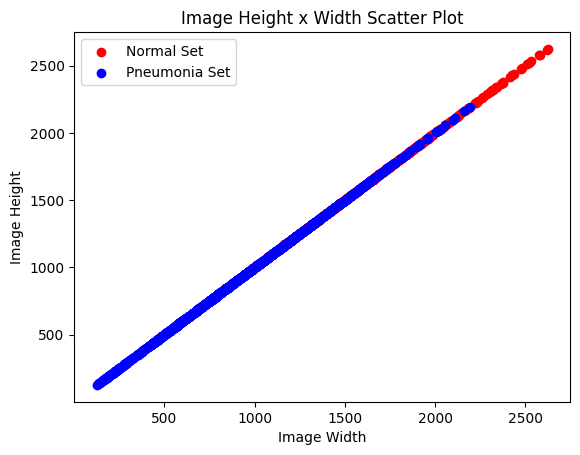

In [ ]:
NORMAL_image_heights_10, NORMAL_image_widths_10 = get_image_sizes('./chest_xray/CROPPED-1.0/train/NORMAL')
PNEUMONIA_image_heights_10, PNEUMONIA_image_widths_10 = get_image_sizes('./chest_xray/CROPPED-1.0/train/PNEUMONIA')
plot_size_scatter(NORMAL_image_widths_10, NORMAL_image_heights_10, PNEUMONIA_image_widths_10, PNEUMONIA_image_heights_10)

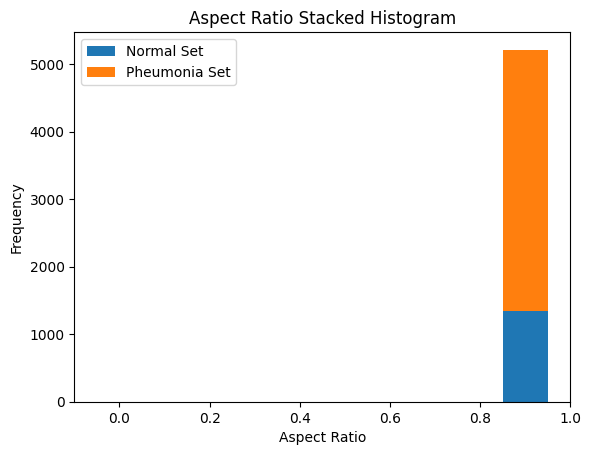

In [ ]:
plot_aspect_ratio_histogram(NORMAL_image_widths_10, NORMAL_image_heights_10, PNEUMONIA_image_widths_10, PNEUMONIA_image_heights_10)